<a href="https://colab.research.google.com/github/Aleeza-GH/ML-learning-journey/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/disease_prediction.csv')

df.sample(5)

,age,blood_pressure,sugar_level,bmi,smoking,disease
35,54,137,107,31.4,1,1
14,58,142,115,32.1,1,1
2,56,140,110,31.2,1,1
38,47,127,97,28.1,0,0
33,49,129,99,28.7,1,1


In [3]:
df.shape

df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             40 non-null     int64  
 1   blood_pressure  40 non-null     int64  
 2   sugar_level     40 non-null     int64  
 3   bmi             40 non-null     float64
 4   smoking         40 non-null     int64  
 5   disease         40 non-null     int64  
dtypes: float64(1), int64(5)
memory usage: 2.0 KB


,0
age,0
blood_pressure,0
sugar_level,0
bmi,0
smoking,0
disease,0


In [4]:
from sklearn.model_selection import train_test_split

X = df.drop('disease', axis=1)
y = df['disease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((32, 5), (8, 5))

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler.mean_

array([ 46.03125, 127.5625 , 100.78125,  27.95625,   0.4375 ])

In [6]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [7]:
y_pred = lr.predict(X_test_scaled)

y_pred

array([1, 1, 0, 0, 1, 0, 1, 1])

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.875
[[2 0]
 [1 5]]
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.83      0.91         6

    accuracy                           0.88         8
   macro avg       0.83      0.92      0.85         8
weighted avg       0.92      0.88      0.88         8



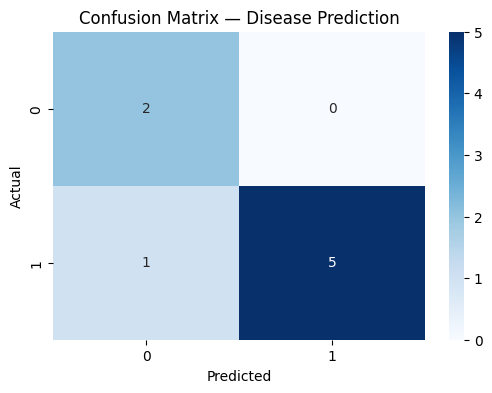

In [9]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Disease Prediction')
plt.show()